In [9]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [10]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



In [11]:
def get_quantum_random_bits(num_bits):
    """
    Generates true random bits by placing qubits in a superposition
    and measuring them.
    State: 1/sqrt(2) (|0> + |1>)
    """
    qc = QuantumCircuit(num_bits, num_bits)
    qc.h(range(num_bits))
    qc.measure(range(num_bits), range(num_bits))

    simulator = BasicSimulator()
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=1).result()

    # Extract bitstring and reverse it to match qubit indices 0 to n-1
    bitstring = list(result.get_counts().keys())[0]
    return bitstring[::-1]

print("Setup complete. Quantum RNG ready.")

Setup complete. Quantum RNG ready.


=== STARTING PLAIN BB84 PROTOCOL ===
Alice's bits:  00001001
Alice's bases: 00011010
Bob's bases:   10001110

Drawing the Quantum Circuit...


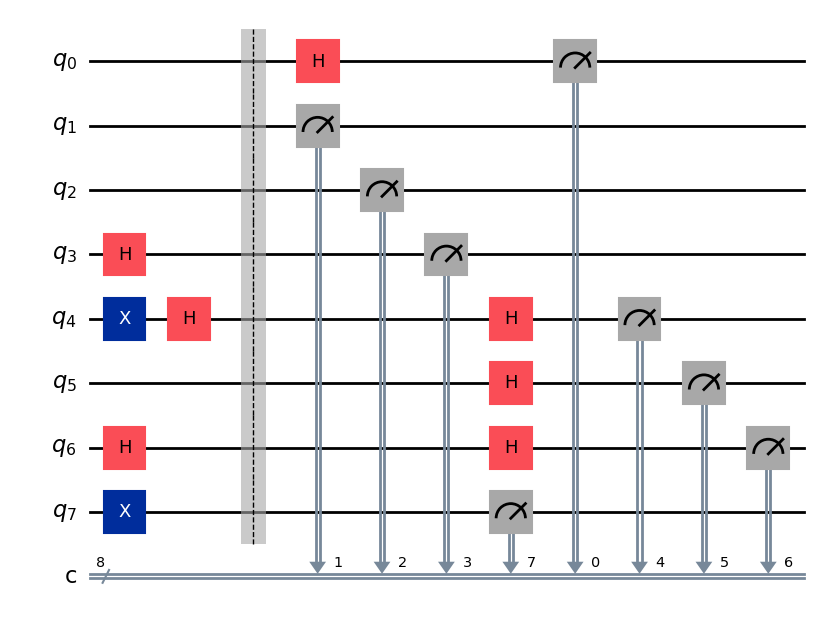


Plotting the Measurement Results...


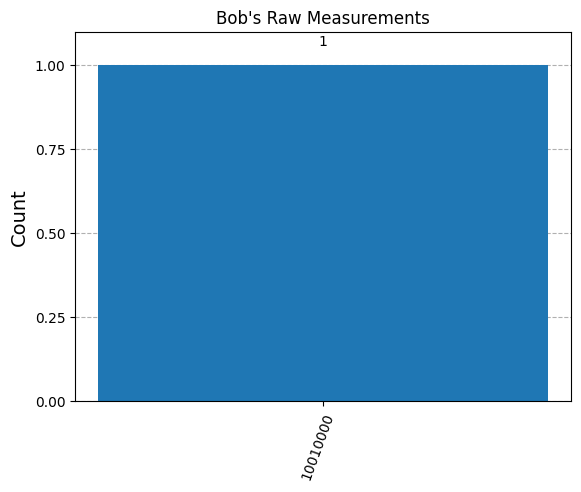


Sifted Key Length: 5 bits
Error Rate: 0.00%
-> SUCCESS: Keys match perfectly. Secure Key: 00101


In [13]:
# --- CELL 2: PLAIN BB84 ---

from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

def run_plain_bb84_with_plots(num_qubits=8): # Reduced to 8 for a cleaner diagram
    print("=== STARTING PLAIN BB84 PROTOCOL ===")

    # 1. ALICE PREPARES
    alice_bits = get_quantum_random_bits(num_qubits)
    alice_bases = get_quantum_random_bits(num_qubits)

    print(f"Alice's bits:  {alice_bits}")
    print(f"Alice's bases: {alice_bases}")

    qc = QuantumCircuit(num_qubits, num_qubits)

    # Encode states
    for i in range(num_qubits):
        if alice_bits[i] == '1':
            qc.x(i)
        if alice_bases[i] == '1':
            qc.h(i)

    qc.barrier() # Visual separator for transmission

    # 2. BOB MEASURES
    bob_bases = get_quantum_random_bits(num_qubits)
    print(f"Bob's bases:   {bob_bases}")

    for i in range(num_qubits):
        if bob_bases[i] == '1':
            qc.h(i)
        qc.measure(i, i)

    # --- PLOT 1: THE CIRCUIT ---
    print("\nDrawing the Quantum Circuit...")
    display(qc.draw("mpl"))

    # Run Simulation
    simulator = BasicSimulator()
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=1).result()
    bob_bits = list(result.get_counts().keys())[0][::-1]

    # --- PLOT 2: THE HISTOGRAM ---
    print("\nPlotting the Measurement Results...")
    display(plot_histogram(result.get_counts(), title="Bob's Raw Measurements"))

    # 3. RECONCILIATION
    alice_key = []
    bob_key = []

    for i in range(num_qubits):
        if alice_bases[i] == bob_bases[i]:
            alice_key.append(alice_bits[i])
            bob_key.append(bob_bits[i])

    print(f"\nSifted Key Length: {len(alice_key)} bits")

    # 4. ERROR CHECKING
    errors = sum(1 for a, b in zip(alice_key, bob_key) if a != b)
    error_rate = errors / len(alice_key) if len(alice_key) > 0 else 0

    print(f"Error Rate: {error_rate * 100:.2f}%")

    if error_rate > 0.10:
        print("-> ALERT: High error rate detected! Channel compromised.")
    else:
        print(f"-> SUCCESS: Keys match perfectly. Secure Key: {''.join(alice_key)}")

# Run the simulation
run_plain_bb84_with_plots(8)